In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


# Load in Data at the chosen band

In [57]:
bands = [4, 5, 6, 7]
wavelengths = [lambda_mm[band] for band in bands]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz"   
}



# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    filename = prefix + band_prefix[band] + file_names['1']
    d = np.load(filename)

    data[wav] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 4.2e+10%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 4.4e+10%: above error tolerance
  warnings.warn(


# Single Plot

In [4]:
colour1 = alma_band_colors[4]
colour2 = alma_band_colors[6]
colour3 = 'dimgrey'
lw = 3
fs = 25

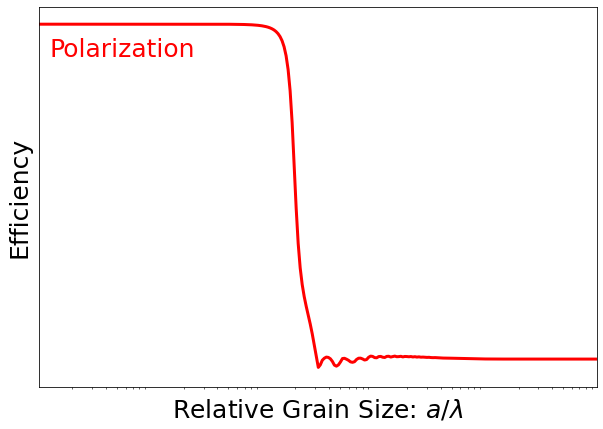

In [80]:
# Pick your wavelength
band = 7

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(1e-3, 1e2)

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

# ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
# ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step1.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

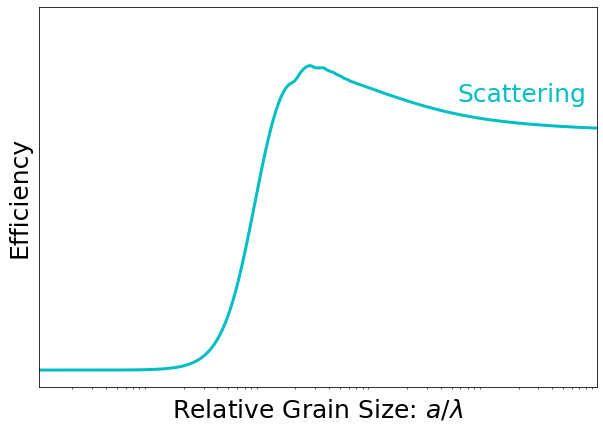

In [84]:
# Pick your wavelength
band = 7

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.set_xticks([])


tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


# ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
# ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step2.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

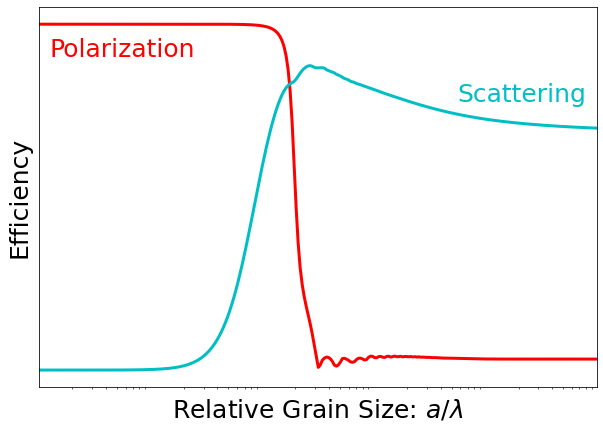

In [85]:
# Pick your wavelength
band = 7

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.set_xticks([])


tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step3.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

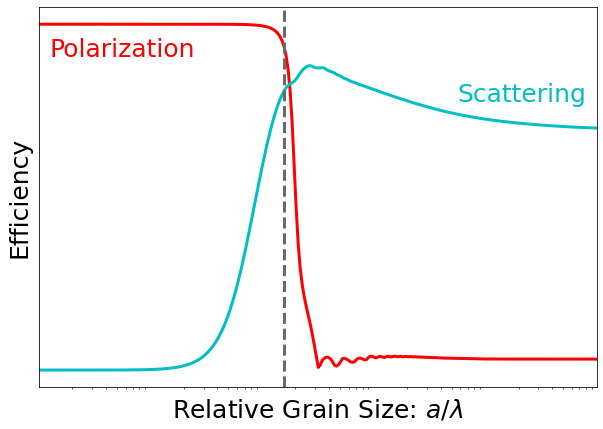

In [86]:
# Pick your wavelength
band = 7

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.set_xticks([])

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step4.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

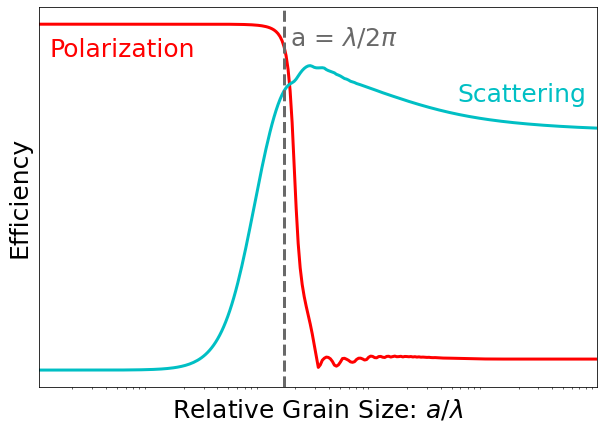

In [87]:
# Pick your wavelength
band = 7

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.set_xticks([])

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_ALL.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

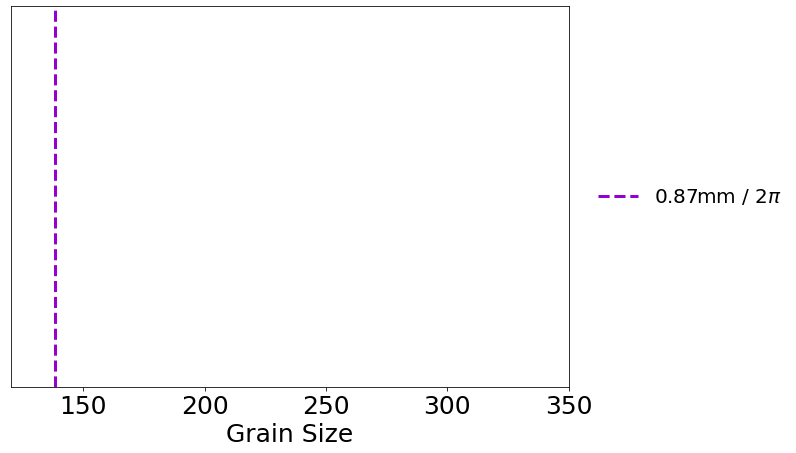

In [65]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)



ax.set_xlim(120, 350)

# Add more vertical lines
i = 3
    
lam_micron = mm_to_micron(wavelengths[i])

val = (lam_micron) / (2 * np.pi)

print('')

ax.axvline(val, ls = '--', lw = lw, color = colours[i], label =f'{wavelengths[i]}mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_Just7.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

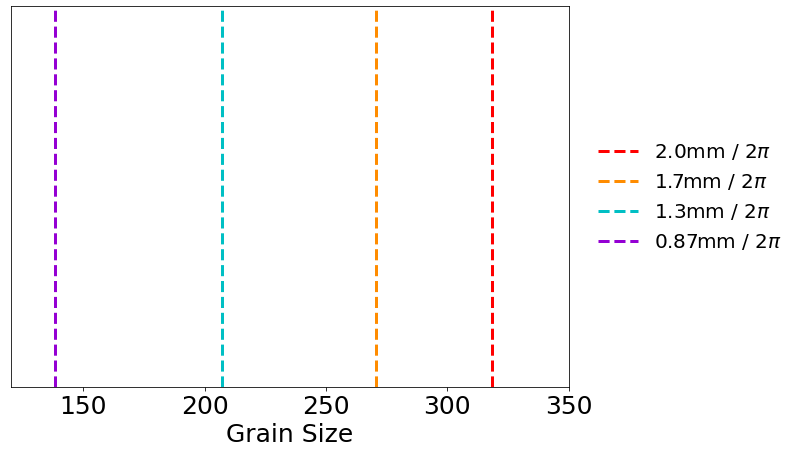

In [66]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)



ax.set_xlim(120, 350)

# Add more vertical lines
for i in range(4):
    
    lam_micron = mm_to_micron(wavelengths[i])
    
    val = (lam_micron) / (2 * np.pi)
    
    print('')
    
    ax.axvline(val, ls = '--', lw = lw, color = colours[i], label =f'{wavelengths[i]}mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_All.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

## Grid

wavelength = 2.0 and peak is at: 0.3183098861837907
wavelength = 1.7 and peak is at: 0.2705634032562221
wavelength = 1.3 and peak is at: 0.20690142601946396
wavelength = 0.87 and peak is at: 0.13846480048994894


Text(0.5, 0.01, 'Relative Grain Size: $a/\\lambda$')

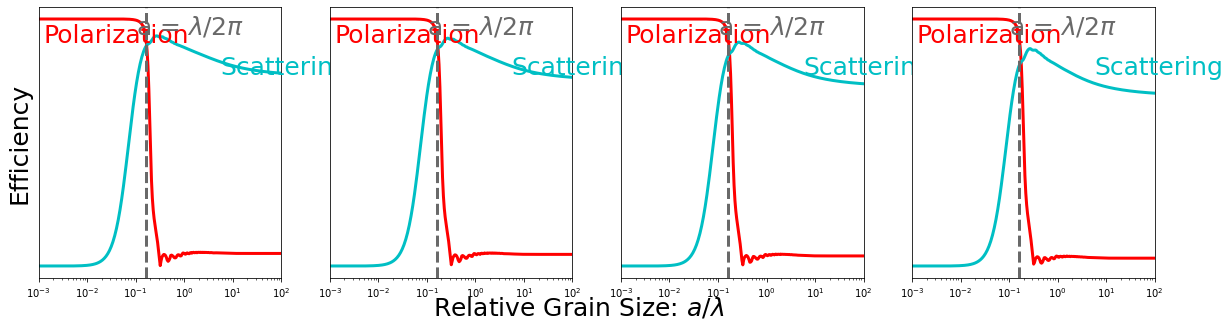

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey = True)

for i in range(4):

    data_band = data[wavelengths[i]]

    a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[i])
    
    print(f'wavelength = {wavelengths[i]} and peak is at: {wavelengths[i]/(2*np.pi)}')

    ax = axes[i]


    ax.set_xscale('log')
    ax.set_xlim(1e-3, 1e2)
    #ax.set_xticks([])
    ax.set_yticks([])
    #ax.tick_params(axis='x', labelbottom=False)


    #ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


    ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
    ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

    ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
    ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

    ax.text(0.4, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
    ax.axvline(1/ (2*np.pi), label = 'a = $\lambda/2\pi$', ls = '--', color = colour3, lw = lw)


axes[0].set_ylabel('Efficiency', fontsize = fs)
fig.supxlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
    
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')